# 198 — GRU 입력 설계 변형: 안 4개 · 시드 3회 · 손실 1회

수치 원본은 같은 폴더의 [`RESULTS.md`](./RESULTS.md)이고, 어긋나면 그쪽이 맞다. 이 노트북은
`evaluate_dl.py --models …`가 남긴 지표 parquet과 아티팩트 `history.json`을 **그림으로만** 다시 읽는다.

질문은 하나다 — 144에서 GRU가 `full`(이력 완비)에서 LightGBM에 RMSE 16.4%p 진 것이
**시퀀스 모델의 한계인가, 입력 1안의 한계인가.**

| 안 | 시퀀스 채널 | 정적 | 가설 |
| --- | --- | --- | --- |
| `base`(V0) | 7 | 요일 4 + 이벤트 5 | 144 기준 |
| `neighbor`(V1) | 16 | 동일 | 89의 인접역 잔차 효과가 시퀀스에서도 나는가 |
| `events_hist`(V2) | 12 | 동일 | 이력 각 날의 이벤트를 주면 대상일 반응이 좋아지는가 |
| `no_events`(V3) | 7 | 요일 4만 | 대조군 — 이벤트 5열이 실제로 기여하는가 |
| `neighbor_no_events` | 16 | 요일 4만 | 계획 밖 1회 — V1·V3이 겹치는가 |

In [1]:
import json
import sys
from pathlib import Path

AI_ROOT = Path.cwd()
while not (AI_ROOT / "app" / "CROWD").exists():
    AI_ROOT = AI_ROOT.parent
sys.path.insert(0, str(AI_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle

figstyle.apply(inline=True)

MODELS = {
    "base_s42": "models/CROWD/dl_gru_s14_20260914-0949",
    "base_s43": "models/CROWD/dl_gru_s14_s43_20260914-1401",
    "base_s44": "models/CROWD/dl_gru_s14_s44_20260914-1402",
    "no_events_s42": "models/CROWD/dl_gru_s14_noev_s42_20260914-1358",
    "no_events_s43": "models/CROWD/dl_gru_s14_noev_s43_20260914-1404",
    "no_events_s44": "models/CROWD/dl_gru_s14_noev_s44_20260914-1406",
    "neighbor_s42": "models/CROWD/dl_gru_s14_neighbor_s42_20260914-1355",
    "neighbor_no_events_s42": "models/CROWD/dl_gru_s14_neighbor_noev_s42_20260914-1410",
    "events_hist_s42": "models/CROWD/dl_gru_s14_events_hist_s42_20260914-1357",
    "base_hd3_s42": "models/CROWD/dl_gru_s14_hd3_s42_20260914-1411",
    "no_events_lstm_s42": "models/CROWD/dl_lstm_s14_noev_s42_20260914-1457",
    "no_events_lstm_s43": "models/CROWD/dl_lstm_s14_noev_s43_20260914-1458",
    "no_events_lstm_s44": "models/CROWD/dl_lstm_s14_noev_s44_20260914-1500",
    "events_fixed_s42": "models/CROWD/dl_gru_s14_evfix_s42_20260914-1501",
    "events_fixed_s43": "models/CROWD/dl_gru_s14_evfix_s43_20260914-1502",
    "events_fixed_s44": "models/CROWD/dl_gru_s14_evfix_s44_20260914-1503"
}
VAL = AI_ROOT / "data" / "CROWD" / "interim" / "validation"

metrics = pd.read_parquet(VAL / "dl_input_metrics.parquet")
grades = pd.DataFrame(json.loads((VAL / "dl_input_grades.json").read_text(encoding="utf-8")))
meta = {k: json.loads((AI_ROOT / v / "meta.json").read_text(encoding="utf-8")) for k, v in MODELS.items()}
history = {k: pd.DataFrame(json.loads((AI_ROOT / v / "history.json").read_text(encoding="utf-8")))
           for k, v in MODELS.items()}

SCEN = ["full", "d7_only", "d1_only", "no_lag"]
VARIANTS = ["base", "neighbor", "events_hist", "no_events", "neighbor_no_events", "base_hd3"]
print(f"지표 {len(metrics):,}행 · 평가 행 {metrics['n'].max():,} · 계열 {metrics['series'].nunique()}")
pd.DataFrame(
    [{"계열": k, "채널": v.get("channels"), "정적": v.get("stat_features"), "δ": v.get("huber_delta", 1.0),
       "시드": v["seed"], "장치": v["device"], "epochs_run": v["epochs_run"], "best_epoch": v["best_epoch"],
       "best_valid": v["best_valid_loss"], "train_s": v["train_seconds"]} for k, v in meta.items()]
).set_index("계열")

지표 1,144행 · 평가 행 1,992,900 · 계열 11


,채널,정적,δ,시드,장치,epochs_run,best_epoch,best_valid,train_s
계열,,,,,,,,,
base_s42,7,NaN,1.0,42,cuda,24,19,0.291675,88.9
base_s43,7,9.0,1.0,43,cuda,18,13,0.293323,87.2
base_s44,7,9.0,1.0,44,cuda,21,16,0.289421,88.9
no_events_s42,7,4.0,1.0,42,cuda,25,20,0.289781,88.4
no_events_s43,7,4.0,1.0,43,cuda,23,18,0.293664,77.8
no_events_s44,7,4.0,1.0,44,cuda,21,16,0.291345,85.8
neighbor_s42,16,9.0,1.0,42,cuda,21,16,0.298378,190.0
neighbor_no_events_s42,16,4.0,1.0,42,cuda,24,19,0.300100,226.2
events_hist_s42,12,9.0,1.0,42,cuda,21,16,0.295768,95.2


## 1. 안별 — lookup 대비 RMSE 개선율

0선(lookup)이 기준이고 **아래로 내려간 막대는 "차라리 평균을 쓰는 게 나았다"**는 뜻이다.
회색 점선이 배포 LightGBM의 `full` 값이다 — 판정 3(−5%p 이내)의 잣대.

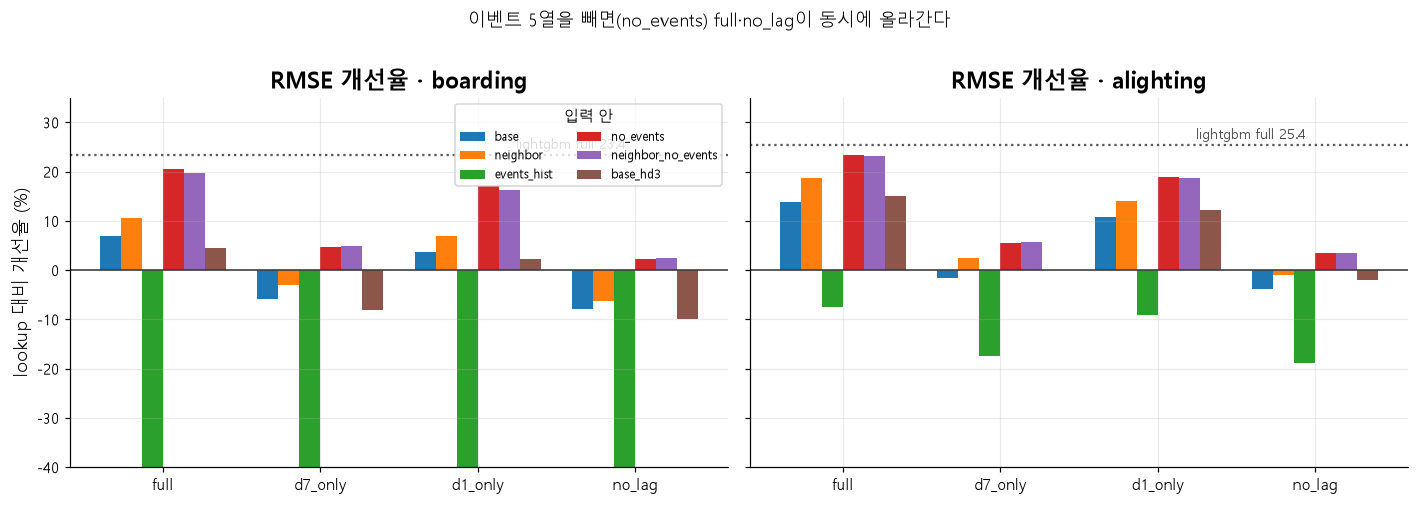

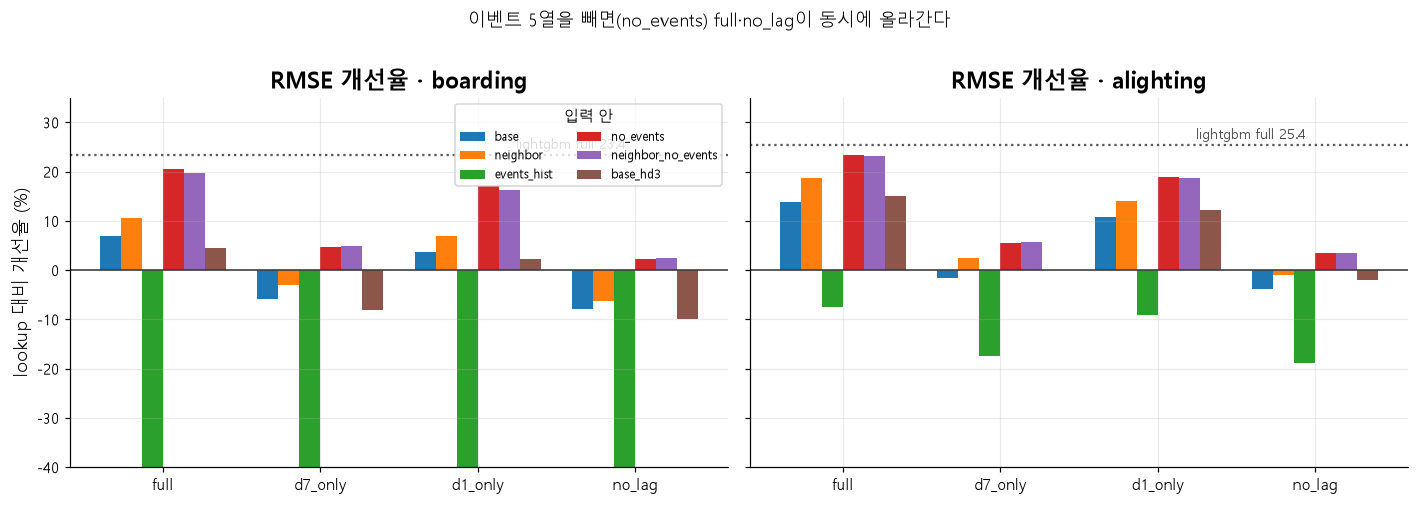

In [2]:
tot = metrics[metrics["axis"] == "전체"].copy()
tot["variant"] = tot["series"].str.replace(r"_s\d+$", "", regex=True)
s42 = tot[tot["series"].str.endswith("_s42") | (tot["series"] == "lightgbm")]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, target in zip(axes, ["boarding", "alighting"]):
    piv = s42[s42["target"] == target].pivot_table(
        index="scenario", columns="variant", values="RMSE_개선율_%"
    ).reindex(index=SCEN, columns=[v for v in VARIANTS if v in s42["variant"].unique()])
    x = np.arange(len(SCEN))
    w = 0.8 / len(piv.columns)
    for i, v in enumerate(piv.columns):
        ax.bar(x + (i - (len(piv.columns) - 1) / 2) * w, piv[v], w, label=v)
    lgb_full = float(
        s42[(s42["target"] == target) & (s42["series"] == "lightgbm")
            & (s42["scenario"] == "full")]["RMSE_개선율_%"].iloc[0]
    )
    ax.axhline(lgb_full, color="0.35", ls=":", lw=1.5)
    ax.annotate(f"lightgbm full {lgb_full:.1f}", (len(SCEN) - 1, lgb_full), xytext=(-6, 4),
                textcoords="offset points", ha="right", fontsize=9, color="0.3")
    ax.axhline(0, color="0.2", lw=1)
    ax.set_xticks(x, SCEN)
    ax.set_title(f"RMSE 개선율 · {target}")
    ax.set_ylim(-40, 35)
axes[0].set_ylabel("lookup 대비 개선율 (%)")
axes[0].legend(title="입력 안", ncols=2, fontsize=8)
fig.suptitle("이벤트 5열을 빼면(no_events) full·no_lag이 동시에 올라간다", y=1.01)
fig.tight_layout()
fig

In [3]:
s42[s42["target"] == "boarding"].pivot_table(
    index="variant", columns="scenario", values=["RMSE_개선율_%", "MAE_개선율_%", "rmse"]
).round(2).reindex([v for v in VARIANTS + ["lightgbm"] if v in s42["variant"].unique()])

MAE_개선율_%                        RMSE_개선율_%                 \
scenario             d1_only d7_only   full  no_lag    d1_only d7_only   full   
variant                                                                         
base                   20.01    2.02  24.68   -1.54       3.60   -5.78   6.99   
neighbor               19.89    4.27  23.80   -0.85       6.87   -3.13  10.49   
events_hist             4.19  -12.28   7.71  -15.42     -76.91  -81.50 -76.02   
no_events              25.17    7.09  29.66    3.50      17.08    4.71  20.46   
neighbor_no_events     24.68    7.73  28.28    4.17      16.31    4.87  19.79   
base_hd3               18.99    1.77  22.89   -0.93       2.27   -8.19   4.56   
lightgbm                9.46  -73.81  29.56 -106.47       6.52  -20.79  23.38   

                             rmse                          
scenario           no_lag d1_only d7_only    full  no_lag  
variant                                                    
base                -7.92  189.05  207.44  182.40  211.62  
neighbor            -6.35  182.63  202.24  175.53  208.56  
events_hist        -82.50  346.93  355.92  345.18  357.89  
no_events            2.23  162.60  186.86  155.98  191.73  
neighbor_no_events   2.48  164.12  186.55  157.29  191.25  
base_hd3            -9.88  191.64  212.17  187.16  215.48  
lightgbm           -36.63  183.31  236.88  150.25  267.94

## 2. 시드 반복 — 개선폭이 시드 분산보다 큰가

판정 2의 그림이다. 시드 42·43·44 세 번의 `full` 개선율 평균과 표준편차를 오차막대로 그린다.
막대 사이 간격(= 안의 효과)이 오차막대(= 시드 노이즈)보다 크면 그 효과는 시드로 설명되지 않는다.

mean                           std                     
scenario            d1_only d7_only   full no_lag d1_only d7_only  full no_lag
variant   target                                                              
base      alighting   12.79   -0.41  16.43  -2.60    2.55    2.34  2.58   2.12
          boarding     4.93   -6.11   8.29  -8.13    6.45    6.19  7.04   6.27
no_events alighting   18.27    4.65  22.60   1.92    0.58    0.99  0.66   1.36
          boarding    16.47    3.77  20.17   1.05    0.59    0.98  0.32   1.03

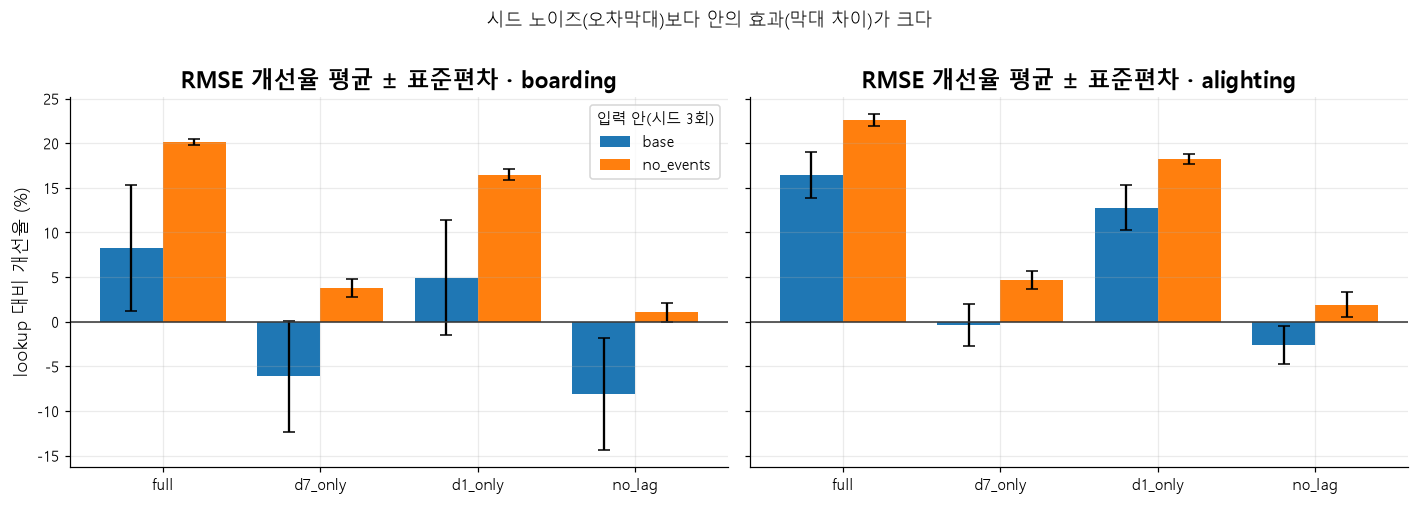

In [4]:
multi = tot.groupby("variant")["series"].nunique()
multi = [v for v in VARIANTS if multi.get(v, 0) >= 2]
g = tot[tot["variant"].isin(multi)].groupby(["variant", "scenario", "target"])["RMSE_개선율_%"]
stat = g.agg(["mean", "std"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, target in zip(axes, ["boarding", "alighting"]):
    sub = stat[stat["target"] == target]
    x = np.arange(len(SCEN))
    w = 0.8 / len(multi)
    for i, v in enumerate(multi):
        row = sub[sub["variant"] == v].set_index("scenario").reindex(SCEN)
        ax.bar(x + (i - (len(multi) - 1) / 2) * w, row["mean"], w, yerr=row["std"],
               capsize=4, label=v)
    ax.axhline(0, color="0.2", lw=1)
    ax.set_xticks(x, SCEN)
    ax.set_title(f"RMSE 개선율 평균 ± 표준편차 · {target}")
axes[0].set_ylabel("lookup 대비 개선율 (%)")
axes[0].legend(title="입력 안(시드 3회)")
fig.suptitle("시드 노이즈(오차막대)보다 안의 효과(막대 차이)가 크다", y=1.01)
fig.tight_layout()
stat.pivot_table(index=["variant", "target"], columns="scenario", values=["mean", "std"]).round(2)

## 3. 학습 곡선

`valid`는 절단 없는 full 이력, `valid(절단)`은 학습과 같은 분포로 이력을 무작위로 자른 검증 손실이다.
**δ=3 실행은 손실 정의 자체가 달라 같은 축에서 비교하지 않는다**(그래서 곡선에서 뺀다).

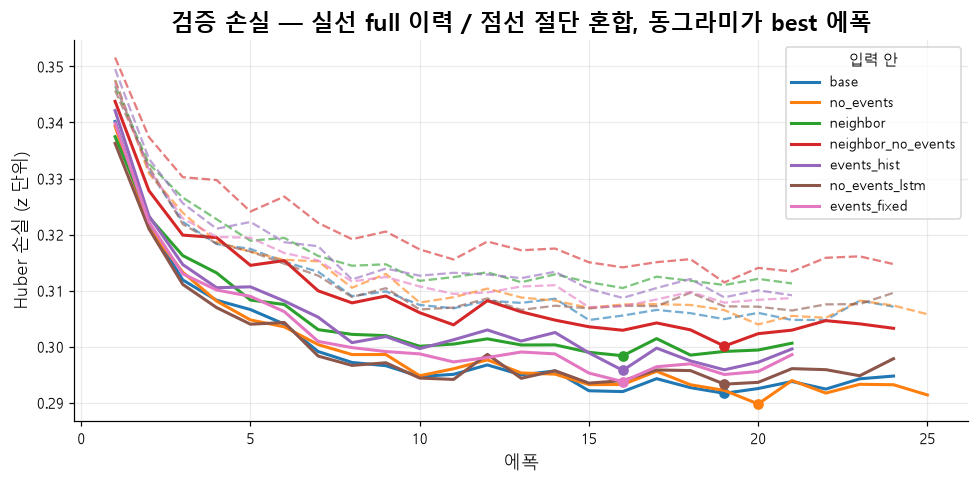

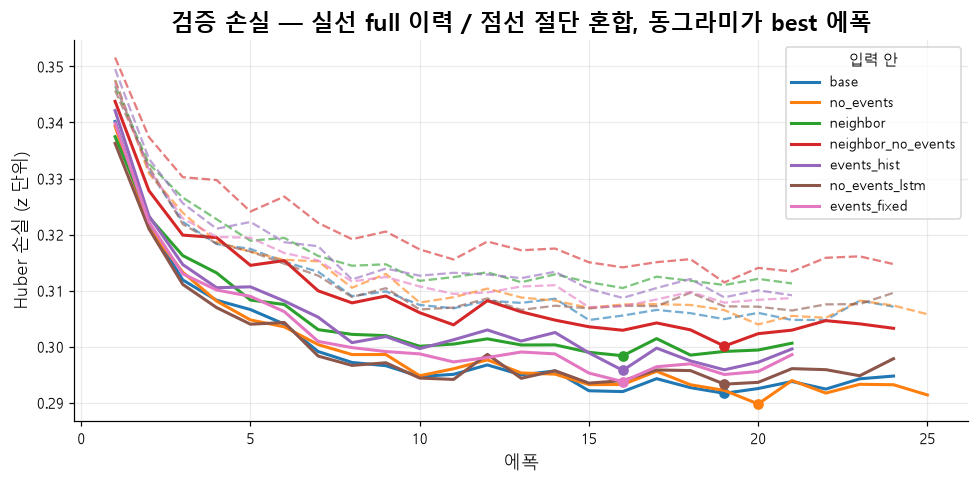

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, h in history.items():
    if meta[name].get("huber_delta", 1.0) != 1.0 or not name.endswith("_s42"):
        continue
    line, = ax.plot(h["epoch"], h["valid_loss"], lw=2, label=name.replace("_s42", ""))
    ax.plot(h["epoch"], h["valid_loss_trunc"], lw=1.5, ls="--", color=line.get_color(), alpha=0.6)
    b = meta[name]["best_epoch"]
    ax.plot([b], [h.loc[b - 1, "valid_loss"]], "o", color=line.get_color(), ms=6)
ax.set_xlabel("에폭")
ax.set_ylabel("Huber 손실 (z 단위)")
ax.set_title("검증 손실 — 실선 full 이력 / 점선 절단 혼합, 동그라미가 best 에폭")
ax.legend(title="입력 안", fontsize=9)
fig.tight_layout()
fig

## 4. 호선 슬라이스 — 2호선이 풀렸는가

144에서 GRU가 `full`에서도 lookup보다 나쁜 유일한 호선이 2호선(−6.16%)이었다.

variant,base,neighbor,events_hist,no_events,neighbor_no_events,base_hd3,lightgbm
group,,,,,,,
1호선,16.26,20.16,4.44,16.97,16.68,15.48,26.90
2호선,-6.16,0.85,-148.04,21.70,21.54,-10.32,22.40
3호선,19.29,15.65,1.32,22.58,20.40,18.01,23.74
4호선,30.45,29.28,21.42,32.48,30.73,28.97,33.09
5호선,13.36,12.91,3.39,15.24,13.71,12.58,20.24
6호선,9.37,8.23,9.08,8.12,8.17,8.42,11.04
7호선,17.63,17.69,1.36,23.15,21.74,18.48,22.93
8호선,34.35,31.83,34.07,35.08,33.26,32.55,33.07


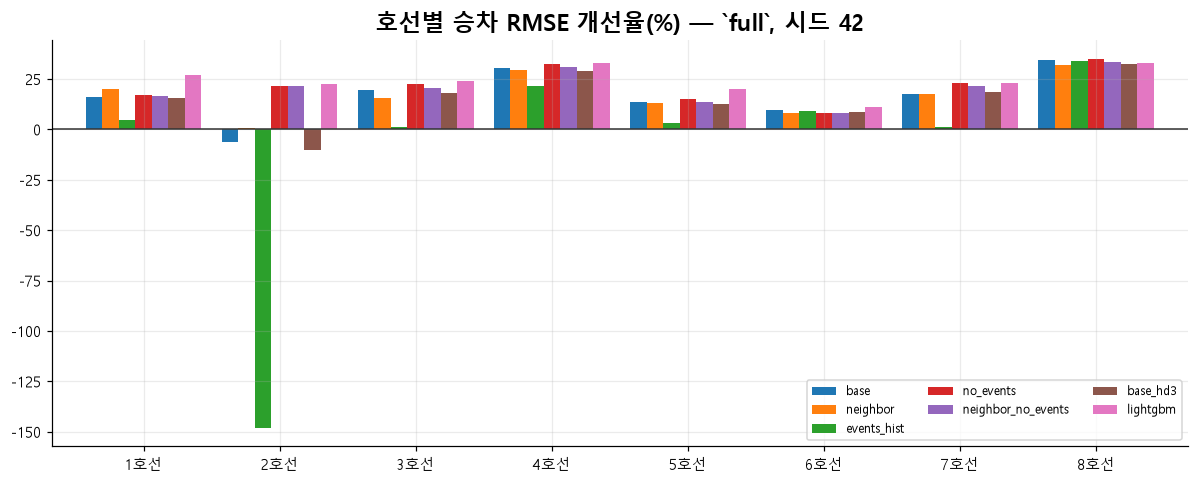

In [6]:
line = metrics[(metrics["axis"] == "line") & (metrics["target"] == "boarding")
                & (metrics["scenario"] == "full")].copy()
line["variant"] = line["series"].str.replace(r"_s\d+$", "", regex=True)
line = line[line["series"].str.endswith("_s42") | (line["series"] == "lightgbm")]
piv = line.pivot_table(index="group", columns="variant", values="RMSE_개선율_%")
piv = piv.reindex(columns=[v for v in VARIANTS + ["lightgbm"] if v in piv.columns])

fig, ax = plt.subplots(figsize=(11, 4.5))
piv.plot.bar(ax=ax, width=0.85)
ax.axhline(0, color="0.2", lw=1)
ax.set_title("호선별 승차 RMSE 개선율(%) — `full`, 시드 42")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8, ncols=3)
fig.tight_layout()
piv.round(2)

## 5. 등급 일치율 — 서비스가 실제로 보여주는 값

임계치 50/100, 30분 셀 기준. 판정용 계열 3개만 돌렸다(판 하나에 2~3분).

In [7]:
grades.set_index("run")[["cells", "등급_일치율_%", "보통이상_재현율_%"]].round(3)

,cells,등급_일치율_%,보통이상_재현율_%
run,,,
lookup,7158957,95.370,83.433
no_events_s42|full,7158957,96.854,89.641
base_s42|full,7158957,96.695,90.069
neighbor_no_events_s42|full,7158957,96.831,90.263


## 6. 후속 — LSTM × V3 · 이벤트 인코딩 수정(`events_fixed`)

1차는 GRU만 9회 돌렸고, 채택 안 V3는 "이벤트 5열을 **뺀**" 안이었다. 그런데 이벤트 열의 표준화를
점검하니 99%가 0인 희소 카운트를 z-점수로 넣어 학습 std가 0.07~0.13이었다 — 2025에서 입력이
z 25.7~88.0까지 튄다. 그래서 1차 결론("이벤트가 해롭다")은 **"이 인코딩으로는 해롭다"**와 구분되지 않는다.
후속 6회(LSTM×V3 3시드 · GRU×`events_fixed` 3시드)가 그 둘을 가른다.

mean                           std                \
scenario                 d1_only d7_only   full no_lag d1_only d7_only  full   
variant        target                                                          
events_fixed   alighting   19.10    5.14  22.27   2.70    0.71    0.72  0.90   
               boarding    16.41    3.44  19.58   1.15    0.78    0.62  0.71   
no_events      alighting   18.27    4.65  22.60   1.92    0.58    0.99  0.66   
               boarding    16.47    3.77  20.17   1.05    0.59    0.98  0.32   
no_events_lstm alighting   19.03    4.79  24.47   2.18    0.64    1.20  0.63   
               boarding    16.62    4.12  20.28   1.56    0.72    1.02  0.09   

                                 
scenario                 no_lag  
variant        target            
events_fixed   alighting   0.57  
               boarding    0.61  
no_events      alighting   1.36  
               boarding    1.03  
no_events_lstm alighting   0.62  
               boarding    0.46

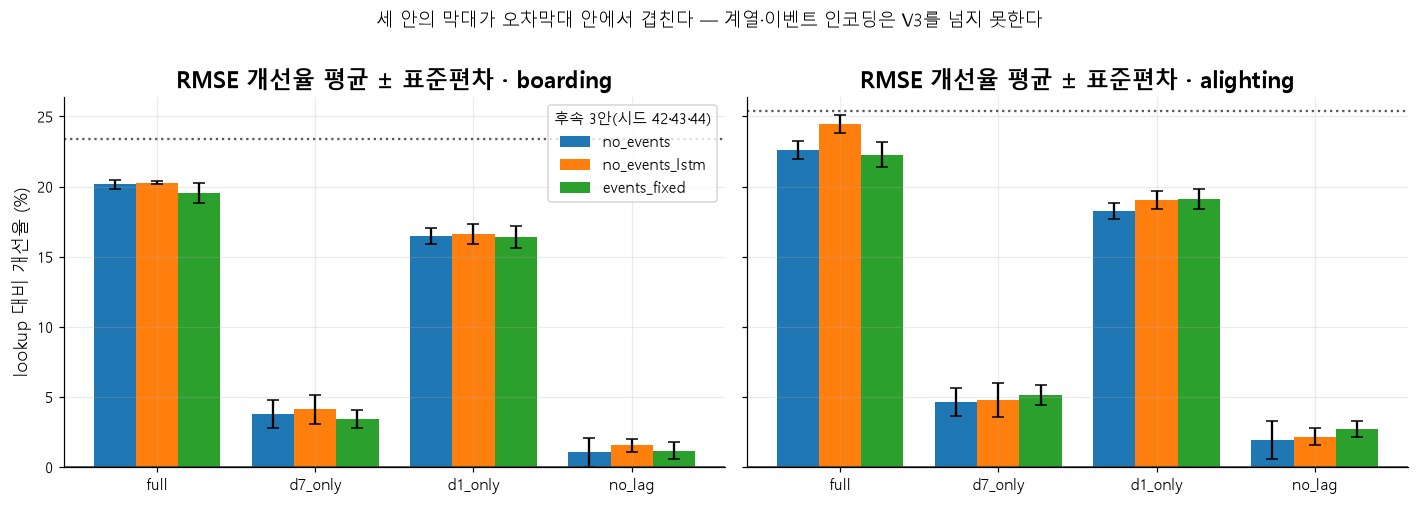

In [8]:
FOLLOWUP = ["no_events", "no_events_lstm", "events_fixed"]
f_metrics = pd.read_parquet(VAL / "dl_input_followup_metrics.parquet")
f_grades = pd.DataFrame(
    json.loads((VAL / "dl_input_followup2_grades.json").read_text(encoding="utf-8"))
)
ftot = f_metrics[f_metrics["axis"] == "전체"].copy()
ftot["variant"] = ftot["series"].str.replace(r"_s\d+$", "", regex=True)
fstat = ftot[ftot["variant"].isin(FOLLOWUP)].groupby(
    ["variant", "scenario", "target"]
)["RMSE_개선율_%"].agg(["mean", "std"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, target in zip(axes, ["boarding", "alighting"]):
    sub = fstat[fstat["target"] == target]
    x = np.arange(len(SCEN))
    w = 0.8 / len(FOLLOWUP)
    for i, v in enumerate(FOLLOWUP):
        row = sub[sub["variant"] == v].set_index("scenario").reindex(SCEN)
        ax.bar(x + (i - (len(FOLLOWUP) - 1) / 2) * w, row["mean"], w, yerr=row["std"],
               capsize=4, label=v)
    lgb_full = float(
        ftot[(ftot["series"] == "lightgbm") & (ftot["target"] == target)
             & (ftot["scenario"] == "full")]["RMSE_개선율_%"].iloc[0]
    )
    ax.axhline(lgb_full, color="0.35", ls=":", lw=1.5)
    ax.axhline(0, color="0.2", lw=1)
    ax.set_xticks(x, SCEN)
    ax.set_title(f"RMSE 개선율 평균 ± 표준편차 · {target}")
axes[0].set_ylabel("lookup 대비 개선율 (%)")
axes[0].legend(title="후속 3안(시드 42·43·44)")
fig.suptitle("세 안의 막대가 오차막대 안에서 겹친다 — 계열·이벤트 인코딩은 V3를 넘지 못한다", y=1.01)
fig.tight_layout()
fstat.pivot_table(index=["variant", "target"], columns="scenario",
                  values=["mean", "std"]).round(2)

### 인코딩은 실제로 고쳐졌는가

학습 구간(2024-01~10) 통계로 2025 이벤트 값을 인코딩했을 때의 **최대 입력값**이다. z-점수는 25.7~88.0,
`log1p_max`는 0.86~1.59 — 고치려던 것은 고쳐졌다. 그런데도 2025 성능이 V3와 같다는 것이 6절의 답이다.

,2025 원값 최대,zscore 최대,log1p_max 최대,0인 비율 %
game_count,2.0,25.670000,1.58,99.49
festival_count,4.0,30.820000,0.90,93.81
festival_short_count,3.0,28.809999,0.86,99.70
festival_long_count,2.0,27.350000,1.00,94.02
festival_min_duration_days,231.0,87.959999,1.43,93.81


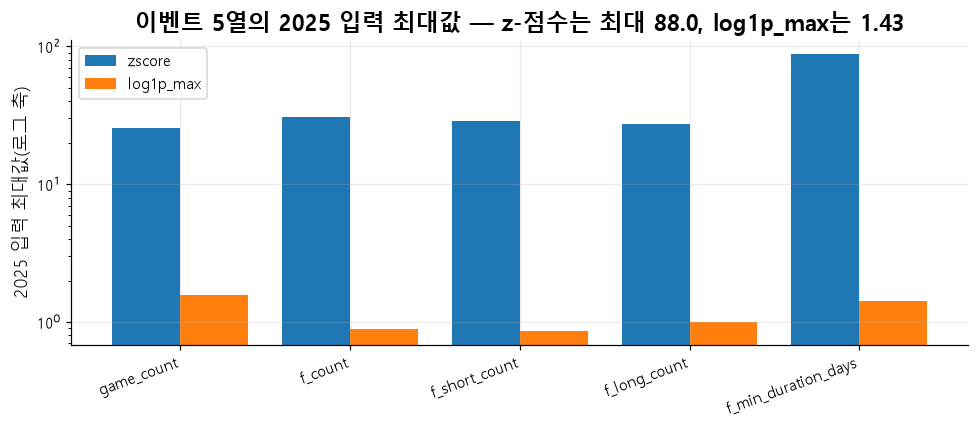

In [9]:
from app.CROWD.pipeline.dl.dataset import EVENT_STATIC_COLS, encode_events

ev_fix = pd.read_parquet(AI_ROOT / MODELS["events_fixed_s42"] / "event_stats.parquet")
ev_z = pd.read_parquet(AI_ROOT / MODELS["no_events_s42"] / "event_stats.parquet")
daily25 = pd.read_parquet(
    AI_ROOT / "data" / "CROWD" / "interim" / "crowd_panel_derived_2024_2025.parquet",
    columns=["date", "station_no", *EVENT_STATIC_COLS],
).drop_duplicates(["date", "station_no"])
daily25 = daily25[pd.to_datetime(daily25["date"]) >= "2025-01-01"]
raw25 = daily25[EVENT_STATIC_COLS].fillna(0.0).to_numpy()
enc = pd.DataFrame(
    {
        "2025 원값 최대": raw25.max(axis=0),
        "zscore 최대": encode_events(raw25, ev_z, "zscore").max(axis=0),
        "log1p_max 최대": encode_events(raw25, ev_fix, "log1p_max").max(axis=0),
        "0인 비율 %": (raw25 == 0).mean(axis=0) * 100,
    },
    index=EVENT_STATIC_COLS,
)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(EVENT_STATIC_COLS))
ax.bar(x - 0.2, enc["zscore 최대"], 0.4, label="zscore")
ax.bar(x + 0.2, enc["log1p_max 최대"], 0.4, label="log1p_max")
ax.set_yscale("log")
ax.set_xticks(x, [c.replace("festival_", "f_") for c in EVENT_STATIC_COLS], rotation=20, ha="right")
ax.set_ylabel("2025 입력 최대값(로그 축)")
ax.set_title("이벤트 5열의 2025 입력 최대값 — z-점수는 최대 88.0, log1p_max는 1.43")
ax.legend()
fig.tight_layout()
enc.round(2)

### 등급 일치율 — 채택 구성(V3)의 GRU·LSTM 2판

후속에서는 채택 구성만 등급으로 확인한다(판 하나에 2~3분). 1차 표(5절)와 같은 셀 집합이다.

In [10]:
f_grades.set_index("run")[["cells", "등급_일치율_%", "보통이상_재현율_%"]].round(3)

,cells,등급_일치율_%,보통이상_재현율_%
run,,,
lookup,7158957,95.370,83.433
no_events_s42|full,7158957,96.854,89.641
no_events_lstm_s42|full,7158957,96.861,90.314


## 7. 읽은 것

결론·판정 ○× 는 [`RESULTS.md`](./RESULTS.md) 4·5절이 원본이다. 그림에서 바로 보이는 것만 적으면:

1. **이벤트 5열을 빼는 것(V3)이 가장 크게 이긴다.** `full`뿐 아니라 `no_lag`까지 같이 올라가고,
   `no_lag`에서 **DL 계열 최초로 lookup을 넘는다**.
2. **`events_hist`(V2)는 크게 실패한다.** 검증(2024-11~12) 손실은 base와 거의 같은데 2025 평가가 무너진다 —
   이벤트 채널이 2024 이벤트 분포에 과적합됐다는 뜻이고, 1번과 같은 방향을 가리킨다.
3. **`neighbor`(V1)는 작지만 일관되게 좋고 2호선 열세를 없앤다.**
4. 시드 오차막대는 작다 — 위 차이들은 시드 노이즈로 설명되지 않는다.
5. **후속(6절): 계열(GRU/LSTM)은 구분되지 않고, 이벤트는 인코딩을 고쳐도 V3를 넘지 못한다.**
   다만 인코딩 수정은 1차의 붕괴·시드 불안정(`full` +8.29 ± 7.04 → +19.58 ± 0.71)을 없앴다 —
   1차 결론은 "이벤트가 해롭다"가 아니라 **"z-인코딩이 해롭고, 이벤트는 고쳐도 보태는 게 없다"**로 정정된다.